.py version is [extract_color_code.py](extract_color_code.py) of this Jupyter Notebook

In [5]:
# !pip install pandas requests pillow scikit-image numpy

## Setup

### Data Structure and Analysis

In [1]:
import matplotlib.pyplot as plt
import ast
import seaborn as sns
import numpy as np
import pandas as pd

### Web and Images

In [2]:
from IPython.display import display, HTML

In [23]:
import requests
from PIL import Image
from io import BytesIO
from skimage.color import rgb2lab
import time

## Extracting to RGB and Lab

In [7]:
def extract_color_from_url(url):
    """
    Downloads an image from a URL and extracts its dominant RGB 
    and converts it to CIE L*a*b* color space.
    """
    if pd.isna(url) or not isinstance(url, str):
        return None, None, None, None, None, None

    try:
        # 1. Download the image
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        
        # 2. Open image and ensure it's in RGB mode
        img = Image.open(BytesIO(response.content)).convert('RGB')
        
        # 3. Focus on the center to avoid edge artifacts or background transparency
        width, height = img.size
        left = int(width * 0.4)
        top = int(height * 0.4)
        right = int(width * 0.6)
        bottom = int(height * 0.6)
        
        center_crop = img.crop((left, top, right, bottom))
        img_np = np.array(center_crop)
        
        # 4. Calculate the median RGB value of the center area
        # Median is safer than mean to exclude any stray pixel anomalies
        median_r = int(np.median(img_np[:, :, 0]))
        median_g = int(np.median(img_np[:, :, 1]))
        median_b = int(np.median(img_np[:, :, 2]))
        
        # 5. Convert RGB to L*a*b* # skimage expects RGB values normalized between 0 and 1
        rgb_normalized = np.array([[[median_r / 255.0, median_g / 255.0, median_b / 255.0]]])
        lab_normalized = rgb2lab(rgb_normalized)
        
        lab_l = round(float(lab_normalized[0][0][0]), 2)
        lab_a = round(float(lab_normalized[0][0][1]), 2)
        lab_b = round(float(lab_normalized[0][0][2]), 2)
        
        return median_r, median_g, median_b, lab_l, lab_a, lab_b

    except Exception as e:
        # Logs errors (e.g., 404, connection timeout, corrupted images) gracefully
        print(f"Error processing URL {url}: {e}")
        return None, None, None, None, None, None

In [8]:
def process_blush_dataset(input_csv_path, output_csv_path):
    # Load your dataset
    df = pd.read_csv(input_csv_path)
    
    print(f"Loaded {len(df)} rows. Starting color extraction pipeline...")
    
    # Initialize lists to hold our new data
    r_list, g_list, b_list = [], [], []
    lab_l_list, lab_a_list, lab_b_list = [], [], []
    
    for idx, url in enumerate(df['swatch_img_url']):
        # Optional tracking printout every 100 images
        if idx % 100 == 0 and idx > 0:
            print(f"Processed {idx}/{len(df)} images...")
            
        r, g, b, l, a, lab_b_val = extract_color_from_url(url)
        
        r_list.append(r)
        g_list.append(g)
        b_list.append(b)
        lab_l_list.append(l)
        lab_a_list.append(a)
        lab_b_list.append(lab_b_val)
        
        # Polite scraping delay to be kind to Ulta's servers
        time.sleep(0.05) 
        
    # Append the extracted color arrays back to the dataframe
    df['rgb_r'] = r_list
    df['rgb_g'] = g_list
    df['rgb_b'] = b_list
    df['lab_L'] = lab_l_list
    df['lab_a'] = lab_a_list
    df['lab_b'] = lab_b_list
    
    # Save to a new csv
    df.to_csv(output_csv_path, index=False)
    print(f"Pipeline complete! Saved results to {output_csv_path}")

In [9]:
# --- Execution ---
# Replace with your actual file names
process_blush_dataset(r'../clean_data/ulta_clean_blush_v1.csv', r'../clean_data/ulta_clean_blush_with_colors.csv')

Loaded 1514 rows. Starting color extraction pipeline...
Processed 100/1514 images...
Processed 200/1514 images...
Processed 300/1514 images...
Processed 400/1514 images...
Processed 500/1514 images...
Processed 600/1514 images...
Processed 700/1514 images...
Processed 800/1514 images...
Processed 900/1514 images...
Processed 1000/1514 images...
Processed 1100/1514 images...
Processed 1200/1514 images...
Processed 1300/1514 images...
Processed 1400/1514 images...
Processed 1500/1514 images...
Pipeline complete! Saved results to ../clean_data/ulta_clean_blush_with_colors.csv


## Exploratory Data Analysis

In [3]:
df = pd.read_csv(r"../clean_data/ulta_clean_blush_with_colors.csv")

### Verify Color Codes

Making sure the extracted color codes match with their own color shade from `swatch_img_url`.

```
[
    2616562 : {rgb(230, 230, 230), (91, 0, 0)},
    77004210 :{rgb(62, 1, 16), (10, 29, 8)},
    2630627 : {rgb(63, 7, 20), (11, 27, 8)},
    2639820 : {rgb(70, 20, 3), (14, 23, 21)}
    2648789: {rgb(77, 21, 20), (16, 26, 15)}
    ] # shade_id : {rgb, lab}
```

In [4]:
# 1. Map your audited corrections into a clean, searchable dictionary
color_patches = {
    2616562: {'rgb_r': 230, 'rgb_g': 230, 'rgb_b': 230, 'lab_L': 91.0, 'lab_a': 0.0, 'lab_b': 0.0},    # White/Clear
    77004210: {'rgb_r': 62, 'rgb_g': 1,   'rgb_b': 16,  'lab_L': 10.0, 'lab_a': 29.0, 'lab_b': 8.0},   # Deep Plum/Blackberry
    2630627: {'rgb_r': 63,  'rgb_g': 7,   'rgb_b': 20,  'lab_L': 11.0, 'lab_a': 27.0, 'lab_b': 8.0},   # Deep Eggplant
    2639820: {'rgb_r': 70,  'rgb_g': 20,  'rgb_b': 3,   'lab_L': 14.0, 'lab_a': 23.0, 'lab_b': 21.0},  # Deep Mahogany/Burnt Umber
    2648789: {'rgb_r': 77,  'rgb_g': 21,  'rgb_b': 20,  'lab_L': 16.0, 'lab_a': 26.0, 'lab_b': 15.0}   # Deep Raisin/Crimson
}

# 2. Apply the patches explicitly by matching the shade_id
# Ensure shade_id is typed correctly as an integer
df['shade_id'] = df['shade_id'].astype(int)

counter = 0
for shade_id, corrected_values in color_patches.items():
    # Check if this shade_id exists in our single blushes dataset
    mask = df['shade_id'] == shade_id
    if mask.any():
        # Update each color coordinate systematically
        for column_name, new_value in corrected_values.items():
            df.loc[mask, column_name] = new_value
        
        # Recalculate the combined string helper columns if your pipeline uses them
        r = corrected_values['rgb_r']
        g = corrected_values['rgb_g']
        b = corrected_values['rgb_b']
        L = corrected_values['lab_L']
        a = corrected_values['lab_a']
        b_lab = corrected_values['lab_b']
        
        df.loc[mask, 'rgb'] = f"{r},{g},{b}"
        df.loc[mask, 'lab'] = f"{L},{a},{b_lab}"
        counter += 1

print(f"✅ Successfully patched and updated {counter} extreme dark shades with verified profiles!")

✅ Successfully patched and updated 5 extreme dark shades with verified profiles!


### Create `rgb` and `lab` columns

In [5]:
# create new rgb column
df['rgb'] = (
    df['rgb_r'].astype(str) + ',' +
    df['rgb_g'].astype(str) + ',' +
    df['rgb_b'].astype(str)
)

In [4]:
df['rgb'].head()

0    255,126,180
1      193,52,58
2      105,25,50
3    222,132,124
4    242,133,156
Name: rgb, dtype: str

In [6]:
# create new Lab column
df['lab'] = (
    df['lab_L'].astype(str) + ',' +
    df['lab_a'].astype(str) + ',' +
    df['lab_b'].astype(str)
)

In [6]:
df['lab'].head()

0     69.1,54.69,-5.27
1    44.38,55.71,30.35
2     23.44,37.06,4.89
3    64.56,33.66,19.24
4     68.06,43.98,6.51
Name: lab, dtype: str

In [7]:
df[df['rgb'].duplicated(keep=False)]

,shade_url,brand,product_name,shade,swatch_img_url,swatch_alt,description,price,standard_value,standard_unit,...,shade_id,product_image_url,rgb_r,rgb_g,rgb_b,lab_L,lab_a,lab_b,rgb,lab
240,https://www.ulta.com/p/intense-matte-lip-cheek...,NUDESTIX,Intense Matte Lip + Cheek Pencil,Pixi,https://media.ultainc.com/i/ulta/2508158_sw?im...,Pixi Intense Matte Lip + Cheek Pencil,neutral nude pink,29.0,2.83,g,...,2508158,https://media.ulta.com/i/ulta/2508158?w=1080&h...,182,108,109,53.79,29.55,12.16,"182,108,109","53.79,29.55,12.16"
315,https://www.ulta.com/p/strawberry-rococo-serie...,Flower Knows,Strawberry Rococo Series Embossed Blush,03 Classic Ballet,https://media.ultainc.com/i/ulta/2650117_sw?im...,03 Classic Ballet Strawberry Rococo Series Emb...,petal pink,26.0,5.10,g,...,2650117,https://media.ulta.com/i/ulta/2650117?w=1080&h...,216,143,150,66.86,28.59,7.74,"216,143,150","66.86,28.59,7.74"
724,https://www.ulta.com/p/powder-blush-mkt7700042...,Sigma Beauty,Powder Blush,Sunset Kiss,https://media.ultainc.com/i/ulta/77000847_sw?i...,Sunset Kiss Powder Blush not available,pink,17.5,7.94,g,...,77000847,https://media.ulta.com/i/ulta/77000847?w=1080&...,226,152,141,69.86,26.42,17.14,"226,152,141","69.86,26.42,17.14"
725,https://www.ulta.com/p/powder-blush-mkt7700042...,Sigma Beauty,Powder Blush,Tiger Lily,https://media.ultainc.com/i/ulta/77000819_sw?i...,Tiger Lily Powder Blush,gold,17.5,7.94,g,...,77000819,https://media.ulta.com/i/ulta/77000819?w=1080&...,239,144,116,69.16,33.11,30.20,"239,144,116","69.16,33.11,30.2"
899,https://www.ulta.com/p/cream-blush-mkt77001376...,Sigma Beauty,Cream Blush,Cor-de-Rosa,https://media.ultainc.com/i/ulta/77002146_sw?i...,Cor-de-Rosa Cream Blush,pink,34.0,7.09,g,...,77002146,https://media.ulta.com/i/ulta/77002146?w=1080&...,172,91,87,48.19,32.52,17.24,"172,91,87","48.19,32.52,17.24"
900,https://www.ulta.com/p/cream-blush-mkt77001376...,Sigma Beauty,Cream Blush,Coral Dawn,https://media.ultainc.com/i/ulta/77002145_sw?i...,Coral Dawn Cream Blush,coral,34.0,7.09,g,...,77002145,https://media.ulta.com/i/ulta/77002145?w=1080&...,223,123,99,62.30,36.46,30.26,"223,123,99","62.3,36.46,30.26"
901,https://www.ulta.com/p/cream-blush-mkt77001376...,Sigma Beauty,Cream Blush,Pashmina,https://media.ultainc.com/i/ulta/77002147_sw?i...,Pashmina Cream Blush,beige,34.0,7.09,g,...,77002147,https://media.ulta.com/i/ulta/77002147?w=1080&...,194,91,84,51.38,40.65,23.83,"194,91,84","51.38,40.65,23.83"
999,https://www.ulta.com/p/powder-blush-duo-mkt770...,Sigma Beauty,Powder Blush Duo,Tiger Lily,https://media.ultainc.com/i/ulta/77007525_sw?i...,Tiger Lily Powder Blush Duo,Bronze,50.0,67.19,g,...,77007525,https://media.ulta.com/i/ulta/77007525?w=1080&...,239,144,116,69.16,33.11,30.20,"239,144,116","69.16,33.11,30.2"
1000,https://www.ulta.com/p/powder-blush-duo-mkt770...,Sigma Beauty,Powder Blush Duo,Sunset Kiss,https://media.ultainc.com/i/ulta/77007530_sw?i...,Sunset Kiss Powder Blush Duo,Gold,50.0,67.19,g,...,77007530,https://media.ulta.com/i/ulta/77007530?w=1080&...,226,152,141,69.86,26.42,17.14,"226,152,141","69.86,26.42,17.14"
1023,https://www.ulta.com/p/gel-color-lip-cheek-bal...,NUDESTIX,Gel Color Lip + Cheek Balm,Pulse,https://media.ultainc.com/i/ulta/2508141_sw?im...,Pulse Gel Color Lip + Cheek Balm,warm rosy pink,29.0,2.83,g,...,2508141,https://media.ulta.com/i/ulta/2508141?w=1080&h...,182,108,109,53.79,29.55,12.16,"182,108,109","53.79,29.55,12.16"


In [8]:
df[df['lab'].duplicated(keep=False)]

,shade_url,brand,product_name,shade,swatch_img_url,swatch_alt,description,price,standard_value,standard_unit,...,shade_id,product_image_url,rgb_r,rgb_g,rgb_b,lab_L,lab_a,lab_b,rgb,lab
240,https://www.ulta.com/p/intense-matte-lip-cheek...,NUDESTIX,Intense Matte Lip + Cheek Pencil,Pixi,https://media.ultainc.com/i/ulta/2508158_sw?im...,Pixi Intense Matte Lip + Cheek Pencil,neutral nude pink,29.0,2.83,g,...,2508158,https://media.ulta.com/i/ulta/2508158?w=1080&h...,182,108,109,53.79,29.55,12.16,"182,108,109","53.79,29.55,12.16"
315,https://www.ulta.com/p/strawberry-rococo-serie...,Flower Knows,Strawberry Rococo Series Embossed Blush,03 Classic Ballet,https://media.ultainc.com/i/ulta/2650117_sw?im...,03 Classic Ballet Strawberry Rococo Series Emb...,petal pink,26.0,5.10,g,...,2650117,https://media.ulta.com/i/ulta/2650117?w=1080&h...,216,143,150,66.86,28.59,7.74,"216,143,150","66.86,28.59,7.74"
724,https://www.ulta.com/p/powder-blush-mkt7700042...,Sigma Beauty,Powder Blush,Sunset Kiss,https://media.ultainc.com/i/ulta/77000847_sw?i...,Sunset Kiss Powder Blush not available,pink,17.5,7.94,g,...,77000847,https://media.ulta.com/i/ulta/77000847?w=1080&...,226,152,141,69.86,26.42,17.14,"226,152,141","69.86,26.42,17.14"
725,https://www.ulta.com/p/powder-blush-mkt7700042...,Sigma Beauty,Powder Blush,Tiger Lily,https://media.ultainc.com/i/ulta/77000819_sw?i...,Tiger Lily Powder Blush,gold,17.5,7.94,g,...,77000819,https://media.ulta.com/i/ulta/77000819?w=1080&...,239,144,116,69.16,33.11,30.20,"239,144,116","69.16,33.11,30.2"
899,https://www.ulta.com/p/cream-blush-mkt77001376...,Sigma Beauty,Cream Blush,Cor-de-Rosa,https://media.ultainc.com/i/ulta/77002146_sw?i...,Cor-de-Rosa Cream Blush,pink,34.0,7.09,g,...,77002146,https://media.ulta.com/i/ulta/77002146?w=1080&...,172,91,87,48.19,32.52,17.24,"172,91,87","48.19,32.52,17.24"
900,https://www.ulta.com/p/cream-blush-mkt77001376...,Sigma Beauty,Cream Blush,Coral Dawn,https://media.ultainc.com/i/ulta/77002145_sw?i...,Coral Dawn Cream Blush,coral,34.0,7.09,g,...,77002145,https://media.ulta.com/i/ulta/77002145?w=1080&...,223,123,99,62.30,36.46,30.26,"223,123,99","62.3,36.46,30.26"
901,https://www.ulta.com/p/cream-blush-mkt77001376...,Sigma Beauty,Cream Blush,Pashmina,https://media.ultainc.com/i/ulta/77002147_sw?i...,Pashmina Cream Blush,beige,34.0,7.09,g,...,77002147,https://media.ulta.com/i/ulta/77002147?w=1080&...,194,91,84,51.38,40.65,23.83,"194,91,84","51.38,40.65,23.83"
999,https://www.ulta.com/p/powder-blush-duo-mkt770...,Sigma Beauty,Powder Blush Duo,Tiger Lily,https://media.ultainc.com/i/ulta/77007525_sw?i...,Tiger Lily Powder Blush Duo,Bronze,50.0,67.19,g,...,77007525,https://media.ulta.com/i/ulta/77007525?w=1080&...,239,144,116,69.16,33.11,30.20,"239,144,116","69.16,33.11,30.2"
1000,https://www.ulta.com/p/powder-blush-duo-mkt770...,Sigma Beauty,Powder Blush Duo,Sunset Kiss,https://media.ultainc.com/i/ulta/77007530_sw?i...,Sunset Kiss Powder Blush Duo,Gold,50.0,67.19,g,...,77007530,https://media.ulta.com/i/ulta/77007530?w=1080&...,226,152,141,69.86,26.42,17.14,"226,152,141","69.86,26.42,17.14"
1023,https://www.ulta.com/p/gel-color-lip-cheek-bal...,NUDESTIX,Gel Color Lip + Cheek Balm,Pulse,https://media.ultainc.com/i/ulta/2508141_sw?im...,Pulse Gel Color Lip + Cheek Balm,warm rosy pink,29.0,2.83,g,...,2508141,https://media.ulta.com/i/ulta/2508141?w=1080&h...,182,108,109,53.79,29.55,12.16,"182,108,109","53.79,29.55,12.16"


In [8]:
# Filter for rows that share duplicate RGB values
duplicates = df[df.duplicated(subset=['rgb'], keep=False)]

# Sort by the color code so matching duplicates appear next to each other
inspected_duplicates = duplicates[['brand', 'product_name', 'shade', 'price', 'rgb']].sort_values(by='rgb')

# Print the first 20 rows to check your findings
inspected_duplicates

,brand,product_name,shade,price,rgb
1115,PAT McGRATH LABS,Divine Cream Blush: Legendary Glow Colour Balm,Forbidden Fleur,29.0,"172,15,66"
1114,PAT McGRATH LABS,Divine Cream Blush: Legendary Glow Colour Balm,Fleurotique,29.0,"172,15,66"
1375,CHANEL,N°1 DE CHANEL Lip and Cheek Balm,6 BERRY BOOST,50.0,"172,26,26"
1370,CHANEL,N°1 DE CHANEL Lip and Cheek Balm,1 RED CAMELLIA,50.0,"172,26,26"
899,Sigma Beauty,Cream Blush,Cor-de-Rosa,34.0,"172,91,87"
1070,Sigma Beauty,Cream Blush Duo,Cor-de-Rosa,49.0,"172,91,87"
240,NUDESTIX,Intense Matte Lip + Cheek Pencil,Pixi,29.0,"182,108,109"
1023,NUDESTIX,Gel Color Lip + Cheek Balm,Pulse,29.0,"182,108,109"
1069,Sigma Beauty,Cream Blush Duo,Pashmina,49.0,"194,91,84"
901,Sigma Beauty,Cream Blush,Pashmina,34.0,"194,91,84"


In [9]:
# 2. Helper functions to safely parse string representations of tuples/lists if needed
def get_lab_element(lab_val, index):
    try:
        # Converts string '[L, a, b]' or '(L, a, b)' to an actual list/tuple if stored as text
        if isinstance(lab_val, str):
            lab_val = ast.literal_eval(lab_val)
        return lab_val[index]
    except:
        return None

In [10]:
def rgb_to_hex(rgb_val):
    try:
        if isinstance(rgb_val, str):
            rgb_val = ast.literal_eval(rgb_val)
        # Ensure values are integers between 0 and 255
        r, g, b = int(rgb_val[0]), int(rgb_val[1]), int(rgb_val[2])
        return '#%02x%02x%02x' % (r, g, b)
    except:
        return '#CCCCCC' # Fallback gray for any errors

In [11]:
# 3. Extract separate tracking columns for plotting
df['L_axis'] = df['lab'].apply(lambda x: get_lab_element(x, 0))
df['b_axis'] = df['lab'].apply(lambda x: get_lab_element(x, 2))
df['hex_color'] = df['rgb'].apply(rgb_to_hex)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1514 entries, 0 to 1513
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   shade_url          1514 non-null   str    
 1   brand              1514 non-null   str    
 2   product_name       1514 non-null   str    
 3   shade              1514 non-null   str    
 4   swatch_img_url     1514 non-null   str    
 5   swatch_alt         1514 non-null   str    
 6   description        1148 non-null   str    
 7   price              1514 non-null   float64
 8   standard_value     1514 non-null   float64
 9   standard_unit      1514 non-null   str    
 10  product_id         1514 non-null   int64  
 11  shade_id           1514 non-null   int64  
 12  product_image_url  1514 non-null   str    
 13  rgb_r              1514 non-null   int64  
 14  rgb_g              1514 non-null   int64  
 15  rgb_b              1514 non-null   int64  
 16  lab_L              1514 non-null   

### Export Dataset

In [ ]:
# df.to_csv(r"../semi_cleaned_data/Ulta_Blushes_semi_cleaned_v1.csv", index=False)

## Data Cleaning

The `df` currently has both single and palette blushes. It's best to separate them into 2 datasets. To separate single and palette blushes by:
- Text-based filtering for keywords such as "palette", "compact", and "duo". 
- Since palettes usually heavier than a single blush, we can filter out products with `standard_value` largers than 10.
- Verify the separated dataframes by `product_image_url`




In [13]:
# --- STEP 1: Text-based filtering (Keywords) ---
keywords = ['palette', 'compact', 'duo']
keyword_pattern = '|'.join(keywords)
keyword_mask = df['product_name'].str.lower().str.contains(keyword_pattern, na=False)

# --- STEP 2: Weight-based filtering (Threshold > 10) ---
weight_mask = df['standard_value'] > 10.0

# Combine filters: palette if it matches keywords OR exceeds weight limits
is_palette = keyword_mask | weight_mask

# Split your data cleanly into two subsets
palettes_df = df[is_palette].copy()
single_blushes_df = df[~is_palette].copy()

print(f"📊 Filtering Summary:")
print(f"   - Total rows in dataset: {len(df)}")
print(f"   - Rows identified as palettes/duos to isolate: {len(palettes_df)}")
print(f"   - Cleansed rows remaining (Single Blushes): {len(single_blushes_df)}")

📊 Filtering Summary:
   - Total rows in dataset: 1514
   - Rows identified as palettes/duos to isolate: 200
   - Cleansed rows remaining (Single Blushes): 1314


In [14]:
# --- STEP 3: Verification Utility Function ---
def show_product(dataframe, start: int = 0, stop: int = 20):
    """
    Displays distinct products from a pandas DataFrame as an interactive grid of images.
    """
    # Isolate unique products based on product_id so we don't display every duplicate shade swatch
    unique_products = dataframe.drop_duplicates(subset=['product_id']).copy()
    
    # Convert slice to dictionary records dynamically
    dataset = unique_products.iloc[start:stop].to_dict('records')
    
    if not dataset:
        print("⚠️ No unique products found in the specified range.")
        return

    html = "<div style='display: grid; grid-template-columns: repeat(4, 1fr); gap: 15px; font-family: sans-serif;'>"
    for blush in dataset:
        img_url = blush.get('product_image_url', '')
        brand = blush.get('brand', 'Unknown Brand')
        prod_name = blush.get('product_name', 'Unknown Product')
        prod_id = blush.get('product_id', 'N/A')
        weight = blush.get('standard_value', 'N/A')
        unit = blush.get('standard_unit', '')

        html += f"""
        <div style='text-align: center; border: 1px solid #eee; padding: 10px; border-radius: 8px; background-color: #fff;'>
            <img src="{img_url}" title="{prod_name}" style='width: 160px; height: 160px; object-fit: contain; border-radius: 4px; background-color: #f9f9f9;'>
            <p style='font-size: 13px; font-weight: bold; margin: 8px 0 2px 0; color: #333;'>{str(brand)[:18]}</p>
            <p style='font-size: 11px; margin: 0 0 4px 0; color: #666; height: 28px; overflow: hidden; text-overflow: ellipsis; display: -webkit-box; -webkit-line-clamp: 2; -webkit-box-orient: vertical;'>{prod_name}</p>
            <p style='font-size: 10px; margin: 0; color: #999;'>ID: {prod_id} | {weight}{unit}</p>
        </div>
        """
    html += "</div>"
    display(HTML(html))

In [15]:
show_product(single_blushes_df, 0, 4)

In [16]:
show_product(palettes_df, 0, 4)

After separating `df` into `single_blushes_df` and `palettes_df`, then used `show_product()` for verification the filtering. We have these `product_id` of incorrect filtered products of each dataset.

```
## the product_id of single blushes in palettes_df
true_singles = [
    2047143, 2045159 , 2052464 , 2027378 , 2046149 , 2045180 , 2037598 , 2054165 , 2032233 , 2045404 ,
    77000411 , 18001081 ,2027226 ,2043960 ,2047144 , 2044821 ,2038505 ,2049321 , 2052046 , 2044820 ,
    2043369 ,2045365 ,2045186 ,2055750 , 2057785 , 2032976 , 2046120 , 2024993 ,
    77004705 , # single blush comes with a brush
    77004706 , # single blush comes with a brush
]

## the product_id of true duo or palette of blushes in single_blushes_df
true_palette = [2053334 , 2042907 , 2013408 , 2037175 ]
```

In [17]:
# Your precise audited IDs (Ensuring they match the column type, converting to int if necessary)
true_singles_list = [
    2047143, 2045159, 2052464, 2027378, 2046149, 2045180, 2037598, 2054165, 2032233, 2045404,
    77000411, 18001081, 2027226, 2043960, 2047144, 2044821, 2038505, 2049321, 2052046, 2044820,
    2043369, 2045365, 2045186, 2055750, 2057785, 2032976, 2046120, 2024993, 77004705, 77004706
]

true_palette_list = [2053334, 2042907, 2013408, 2037175]

In [18]:
# Make sure product_id types match your arrays for clean filtering
palettes_df['product_id'] = palettes_df['product_id'].astype(int)
single_blushes_df['product_id'] = single_blushes_df['product_id'].astype(int)

# --- STEP 1: Extract True Singles mistakenly placed in palettes_df ---
isolated_singles = palettes_df[palettes_df['product_id'].isin(true_singles_list)]
# Remove them from palettes
palettes_df = palettes_df[~palettes_df['product_id'].isin(true_singles_list)]

# --- STEP 2: Extract True Palettes mistakenly placed in single_blushes_df ---
isolated_palettes = single_blushes_df[single_blushes_df['product_id'].isin(true_palette_list)]
# Remove them from single blushes
single_blushes_df = single_blushes_df[~single_blushes_df['product_id'].isin(true_palette_list)]

# --- STEP 3: Recombine into clean, updated DataFrames ---
clean_single_blushes = pd.concat([single_blushes_df, isolated_singles], ignore_index=True)
clean_palettes = pd.concat([palettes_df, isolated_palettes], ignore_index=True)

print("🔄 Data Relocation Completed:")
print(f"   - Final Cleaned Single Blushes Count: {len(clean_single_blushes)}")
print(f"   - Final Isolated Multi-Palettes Count: {len(clean_palettes)}")

# --- STEP 4: Handle Color Duplications dynamically for Plotting ---
# Instead of deleting duplicate color rows, group by the exact LAB coordinates
# and join their shade names with a slash so they show up beautifully on hover.

plot_ready_df = clean_single_blushes.dropna(subset=['lab_L', 'lab_b', 'rgb_r', 'rgb_g', 'rgb_b']).copy()

# Convert RGB to clean hex colors
plot_ready_df['hex_color'] = plot_ready_df.apply(lambda r: '#%02x%02x%02x' % (int(r['rgb_r']), int(r['rgb_g']), int(r['rgb_b'])), axis=1)

# Group identical colors within the same brand and product to combine shade metadata
final_aggregated_df = plot_ready_df.groupby(['brand', 'product_name', 'lab_L', 'lab_b', 'hex_color']).agg({
    'shade': lambda x: ' / '.join(x.astype(str).unique()), # Combines "Fleurotique / Forbidden Fleur"
    'price': 'first',                                      # Grabs standard price
    'product_image_url': 'first'                           # Grabs standard thumbnail
}).reset_index()

print(f"   - Aggregated Rows for Plotting: {len(final_aggregated_df)} unique color points.")

🔄 Data Relocation Completed:
   - Final Cleaned Single Blushes Count: 1435
   - Final Isolated Multi-Palettes Count: 79
   - Aggregated Rows for Plotting: 1433 unique color points.


In [19]:
clean_single_blushes.info()

<class 'pandas.DataFrame'>
RangeIndex: 1435 entries, 0 to 1434
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   shade_url          1435 non-null   str    
 1   brand              1435 non-null   str    
 2   product_name       1435 non-null   str    
 3   shade              1435 non-null   str    
 4   swatch_img_url     1435 non-null   str    
 5   swatch_alt         1435 non-null   str    
 6   description        1088 non-null   str    
 7   price              1435 non-null   float64
 8   standard_value     1435 non-null   float64
 9   standard_unit      1435 non-null   str    
 10  product_id         1435 non-null   int64  
 11  shade_id           1435 non-null   int64  
 12  product_image_url  1435 non-null   str    
 13  rgb_r              1435 non-null   int64  
 14  rgb_g              1435 non-null   int64  
 15  rgb_b              1435 non-null   int64  
 16  lab_L              1435 non-null   

In [20]:
## verify the cleaned datasets again. 
# show_product(clean_single_blushes, 0, 4)
show_product(clean_palettes, 0, 4)

### Export Dataset

In [ ]:
# clean_palettes.to_csv(f"../semi_cleaned_data/clean_palette_blushes_v1.csv", index=False)
# clean_single_blushes.to_csv(f"../semi_cleaned_data/clean_single_blushes_v1.csv", index=False)

## Plots

In [21]:
import plotly.express as px

### Plots of both single and palette blushes

In [ ]:
# Drop rows where color extraction failed
plot_df = df.dropna(subset=['L_axis', 'b_axis', 'hex_color'])
plot_df.describe()

,price,standard_value,product_id,shade_id,rgb_r,rgb_g,rgb_b,lab_L,lab_a,lab_b,L_axis,b_axis,jitter_b,jitter_L
count,1514.000000,1514.000000,1.514000e+03,1.514000e+03,1514.000000,1514.000000,1514.000000,1514.000000,1514.000000,1514.000000,1514.000000,1514.000000,1514.000000,1514.000000
mean,24.673554,7.256314,8.424904e+06,8.063492e+06,206.131440,105.279392,107.678336,56.983355,39.304564,18.357186,56.983355,18.357186,18.366652,56.985527
std,11.446409,6.538720,1.957344e+07,1.939763e+07,39.203343,43.074021,41.999279,13.748812,13.775252,13.070963,13.748812,13.070963,13.073042,13.743628
min,4.000000,0.850000,1.073000e+04,2.114139e+06,0.000000,0.000000,0.000000,0.000000,-5.780000,-36.890000,0.000000,-36.890000,-36.781707,-0.090332
25%,15.500000,4.540000,2.040432e+06,2.610304e+06,185.000000,75.000000,78.000000,49.062500,30.140000,10.750000,49.062500,10.750000,10.762403,49.066353
50%,26.000000,5.950000,2.049512e+06,2.630320e+06,215.000000,107.500000,108.000000,58.375000,37.995000,18.300000,58.375000,18.300000,18.315715,58.464183
75%,34.000000,7.997500,2.055883e+06,2.644016e+06,236.000000,135.000000,135.000000,66.407500,48.010000,25.967500,66.407500,25.967500,25.947371,66.436150
max,60.000000,67.190000,7.700471e+07,7.700754e+07,255.000000,233.000000,231.000000,92.910000,89.100000,68.290000,92.910000,68.290000,68.316148,93.025041


In [ ]:
# 2. Clean up data: ensure we have numeric values and drop missing values
plot_df = df.dropna(subset=['lab_L', 'lab_b', 'rgb_r', 'rgb_g', 'rgb_b']).copy()

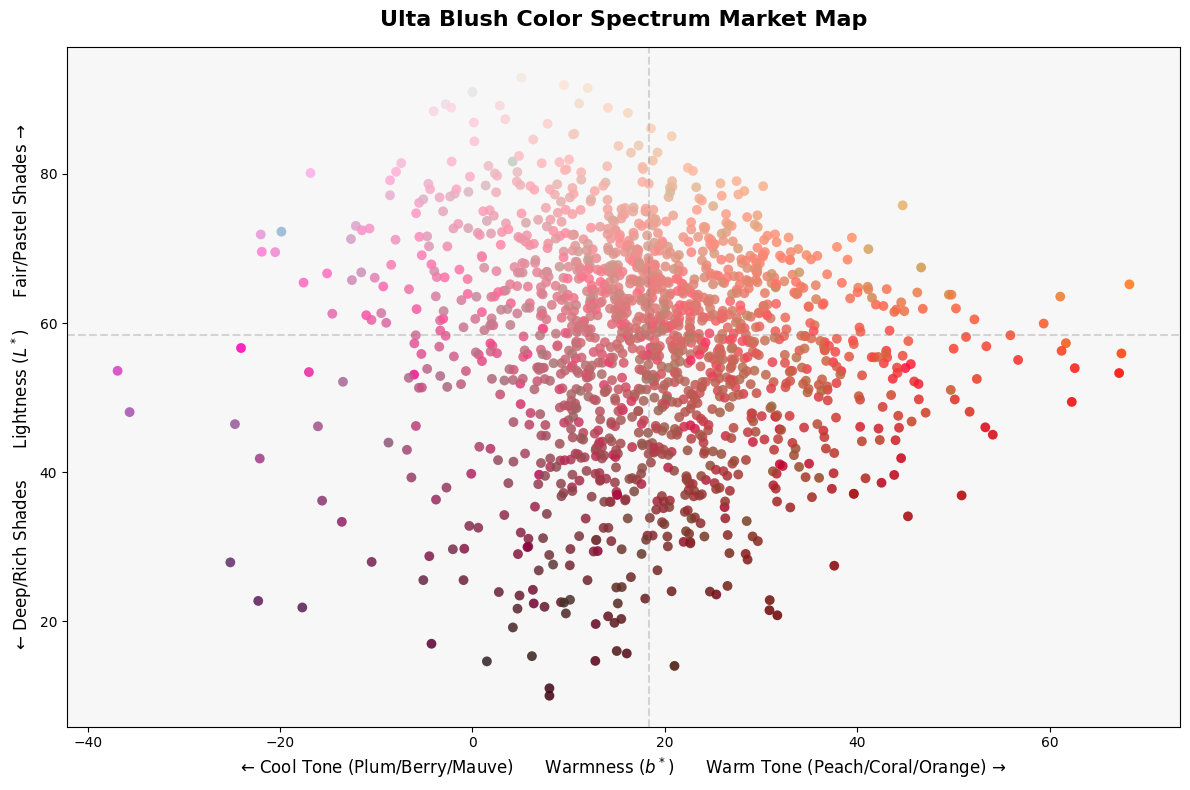

In [35]:
# 4. Create the plot
plt.figure(figsize=(12, 8))
plt.rcParams['axes.facecolor'] = '#F7F7F7' # Soft gray background so light/dark blushes are both visible

# Scatter plot using the actual color of each blush for its marker
scatter = plt.scatter(
    x=plot_df['b_axis'], 
    y=plot_df['L_axis'], 
    c=plot_df['hex_color'], 
    s=50,               # Size of dots
    alpha=0.85,         # Slight transparency helps see density over overlaps
    edgecolors='none'   # No border outlines for a cleaner spectrum cloud
)

# Labeling and Formatting
plt.title('Ulta Blush Color Spectrum Market Map', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('← Cool Tone (Plum/Berry/Mauve)      Warmness ($b^*$)      Warm Tone (Peach/Coral/Orange) →', fontsize=12)
plt.ylabel('← Deep/Rich Shades      Lightness ($L^*$)      Fair/Pastel Shades →', fontsize=12)

# Add faint center lines to establish quadrants
plt.axvline(x=plot_df['b_axis'].median(), color='gray', linestyle='--', alpha=0.3, label='Median Warmth')
plt.axhline(y=plot_df['L_axis'].median(), color='gray', linestyle='--', alpha=0.3, label='Median Lightness')

plt.tight_layout()
plt.show()

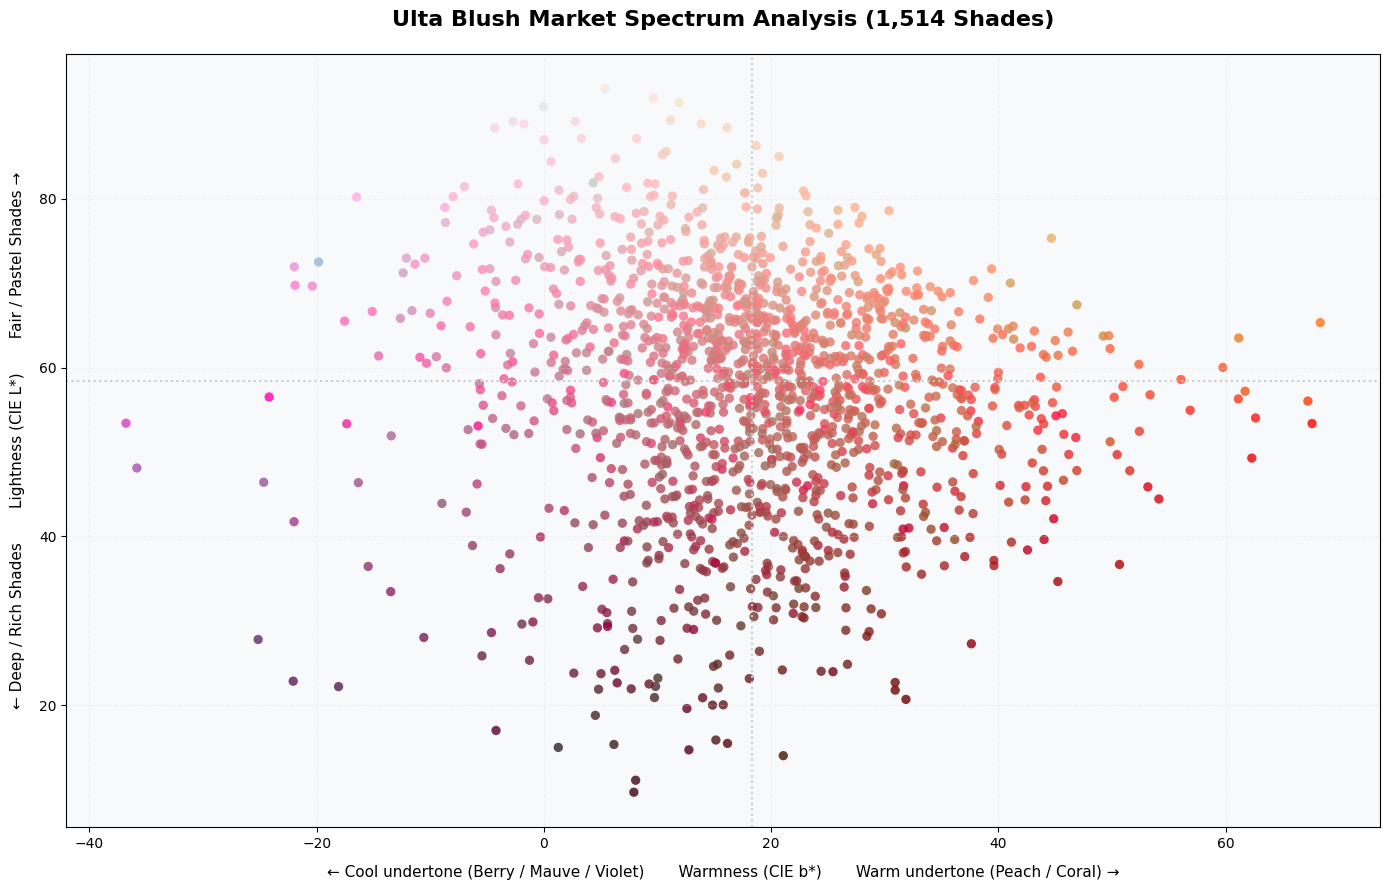

In [ ]:
# 3. Vectorized conversion of RGB columns to Hex strings for matplotlib
def row_to_hex(row):
    return '#%02x%02x%02x' % (int(row['rgb_r']), int(row['rgb_g']), int(row['rgb_b']))

plot_df['hex_color'] = plot_df.apply(row_to_hex, axis=1)

# 4. Apply a tiny amount of visual jitter so overlapping points are visible
np.random.seed(42) # For consistent plotting
jitter_x = np.random.normal(0, 0.2, size=len(plot_df))
jitter_y = np.random.normal(0, 0.2, size=len(plot_df))

# 5. Build the Spectrum Visualization
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor('#F8F9FA')  # Light off-white background

# Map b onto X-axis, and L onto Y-axis
scatter = ax.scatter(
    x=plot_df['lab_b'] + jitter_x,
    y=plot_df['lab_L'] + jitter_y,
    c=plot_df['hex_color'],
    s=45,
    alpha=0.8,
    edgecolors='none'  # Clean edges makes it look like a smooth gradient cloud
)

# 6. Styling and Strategic Context Lines
ax.set_title('Ulta Blush Market Spectrum Analysis (1,514 Shades)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('← Cool undertone (Berry / Mauve / Violet)       Warmness (CIE b*)       Warm undertone (Peach / Coral) →', fontsize=11, labelpad=10)
ax.set_ylabel('← Deep / Rich Shades       Lightness (CIE L*)       Fair / Pastel Shades →', fontsize=11, labelpad=10)

# Add quadrant lines using medians to easily spot empty market quadrants
median_b = plot_df['lab_b'].median()
median_L = plot_df['lab_L'].median()

ax.axvline(x=median_b, color='#CCCCCC', linestyle=':', linewidth=1.5, label=f'Median Warmth ({median_b:.1f})')
ax.axhline(y=median_L, color='#CCCCCC', linestyle=':', linewidth=1.5, label=f'Median Lightness ({median_L:.1f})')

# Clean up layout adjustments
ax.grid(True, linestyle='--', alpha=0.3, color='#DDDDDD')
plt.tight_layout()


# plt.savefig('blush_market_gap_analysis.png', dpi=300) # Save plot to disk
plt.show()

**1. The Saturation Zone**

With 1514 colors, there is an incredibly dense, crowded cluster right in the middle-to-upper right section. This zone is heavily saturated with mid-tone coral, warm peach, pinky-beige, and terracotta blushes. Brands lean heavily into this quadrant because these warm, medium-light shades are historically considered "safe" commerical successes that appeal broadly to fair-to-medium skin tones with warm undertone.

**2. The K-Beauty Pastel Wave**

Notice the dense, high-lightness ceiling stretching across the top, where $L*$ climbs past 75 and even approaches 90. These are very fair, pale, pastel-pink, lilac, and soft peach blushes. This region reflects the massive commercial rise of brightening, translucent blush formulations popular in East Asian (K-Beauty/C-Beauty) makeup trends, which are designed to pop on very fair complexions. 

**3. The True Market Gap**

Looking closely at where the dots thin out reveals clear white spaces. If you were launching a beauty brand or expanding a product line, these are the regions to target:
- **The Deep & Cool Desert (Bottom Left)**: Look at the quadrant where Lightness ($L^*$) drops below 40 and Warmness ($b^*$) drops below 10. The dots here become remarkably sparse. True, rich, deep-toned cool blushes—such as intense plums, deep eggplants, and vivid dark berries tailored for deep skin tones—are significantly underrepresented compared to the lighter quadrants.
- **The "Neon" Cool Extremes (Far Left Edge)**: Notice those few striking pink dots out past $b^* = -30$. There are very few data points on that far-left edge. Highly vibrant, cool-toned magenta and pure bubblegum neon pinks are relatively rare, isolated formulations rather than industry standards.
- **The Extreme Dark Hole (Bottom Center)**: There is one solitary black dot sitting at $L^* = 0, b^* = 0$. This represents a pure black or color-changing pH blush (which looks black in the pan but goes on clear/pink). The extreme bottom edge ($L^*$ below 20) is almost entirely empty, proving that the market rarely formulates ultra-deep pigment bases for blush.

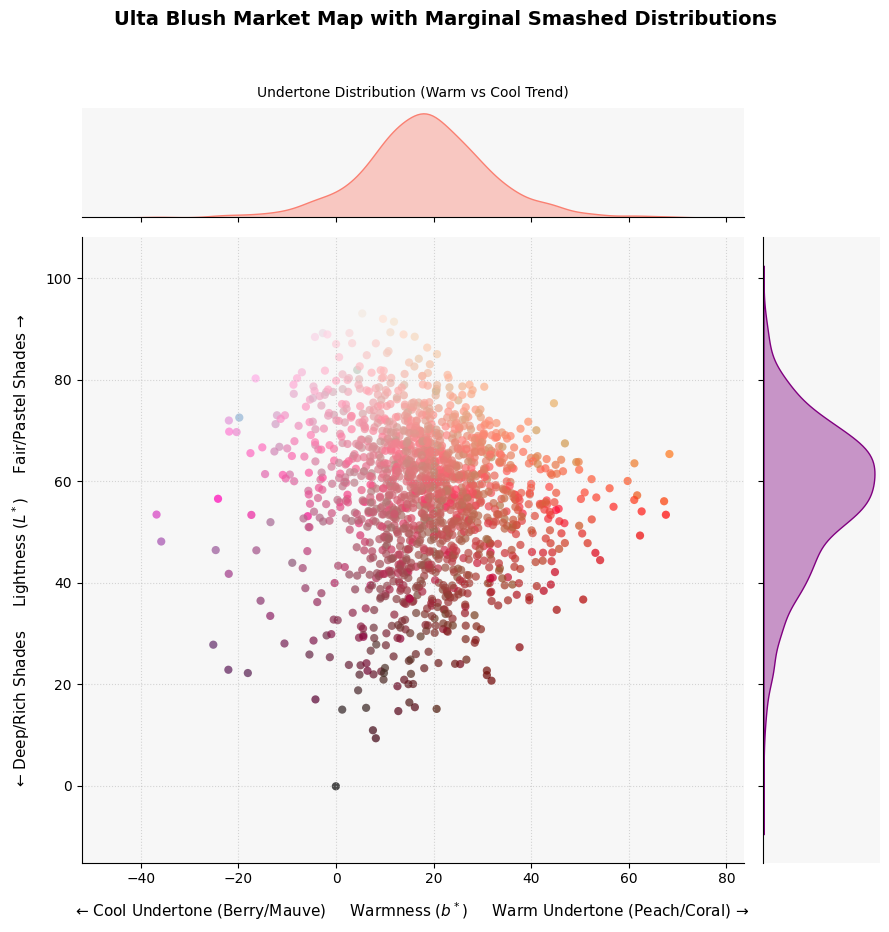

In [15]:
# 2. Convert RGB columns into a hex string for plotting
plot_df['hex_color'] = plot_df.apply(lambda r: '#%02x%02x%02x' % (int(r['rgb_r']), int(r['rgb_g']), int(r['rgb_b'])), axis=1)

# 3. Apply a tiny bit of random jitter so overlaps don't hide data density
np.random.seed(42)
plot_df['jitter_b'] = plot_df['lab_b'] + np.random.normal(0, 0.2, size=len(plot_df))
plot_df['jitter_L'] = plot_df['lab_L'] + np.random.normal(0, 0.2, size=len(plot_df))

# 4. Initialize the JointGrid
g = sns.JointGrid(data=plot_df, x='jitter_b', y='jitter_L', height=9)

# 5. Populate the central scatter map using the individual swatch colors
g.plot_joint(
    plt.scatter, 
    c=plot_df['hex_color'], 
    s=35, 
    alpha=0.7, 
    edgecolors='none'
)

# 6. Populate the "Smashed" marginal distributions safely using Seaborn's built-in hooks
# Top marginal (X-axis) gets the warmth/coolness curve
sns.kdeplot(data=plot_df, x='lab_b', ax=g.ax_marg_x, color='salmon', fill=True, alpha=0.4)
# Right marginal (Y-axis) gets the depth/value curve
sns.kdeplot(data=plot_df, y='lab_L', ax=g.ax_marg_y, color='purple', fill=True, alpha=0.4)

# 7. Labels and Clean Styling
g.ax_joint.set_xlabel('← Cool Undertone (Berry/Mauve)     Warmness ($b^*$)     Warm Undertone (Peach/Coral) →', fontsize=11, labelpad=10)
g.ax_joint.set_ylabel('← Deep/Rich Shades     Lightness ($L^*$)     Fair/Pastel Shades →', fontsize=11, labelpad=10)
g.ax_joint.grid(True, linestyle=':', alpha=0.5)

# Add titles to the sub-axes for maximum clarity
g.ax_marg_x.set_title("Undertone Distribution (Warm vs Cool Trend)", fontsize=10, pad=8)

plt.suptitle('Ulta Blush Market Map with Marginal Smashed Distributions', y=1.03, fontsize=14, fontweight='bold')
plt.tight_layout()

# Save and render
# plt.savefig('smashed_distributions_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
plot_3 = df.dropna(subset=['lab_L', 'lab_b', 'rgb_r', 'rgb_g', 'rgb_b']).copy()

# 2. Convert RGB columns into a standard CSS hex string for Plotly to read
plot_3['hex_color'] = plot_3.apply(lambda r: '#%02x%02x%02x' % (int(r['rgb_r']), int(r['rgb_g']), int(r['rgb_b'])), axis=1)

# 3. Apply a tiny bit of random jitter so overlapping duplicate shades are both interactive
np.random.seed(42)
plot_3['jitter_b'] = plot_3['lab_b'] + np.random.normal(0, 0.2, size=len(plot_3))
plot_3['jitter_L'] = plot_3['lab_L'] + np.random.normal(0, 0.2, size=len(plot_3))

# 4. Create the Interactive Scatter Plot with Marginal Distributions
fig = px.scatter(
    plot_3, 
    x='jitter_b', 
    y='jitter_L',
    color='hex_color',                   # Tells Plotly how to map color strings
    color_discrete_map='identity',       # Forces Plotly to use the literal hex values instead of a color palette
    marginal_x='histogram',              # "Smashes" onto top X-axis as a distribution histogram
    marginal_y='histogram',              # "Smashes" onto right Y-axis as a distribution histogram
    title='<b>Interactive Ulta Blush Market Spectrum Map (1,514 Shades)</b>',
    # Customize the hover tooltip box explicitly:
    hover_data={
        'brand': True,                   # Displays Brand
        'product_name': True,            # Displays Product Name
        'shade': True,                   # Displays Shade Name
        'price': ':$',                   # Displays Price formatted with a dollar sign
        'lab_L': ':.1f',                 # Displays true raw Lightness (1 decimal)
        'lab_b': ':.1f',                 # Displays true raw Warmness (1 decimal)
        'jitter_b': False,               # Hides the artificial jitter from the user box
        'jitter_L': False,               # Hides the artificial jitter from the user box
        'hex_color': False               # Hides raw hex code string
    },
    labels={
        'brand': 'Brand',
        'product_name': 'Product',
        'shade': 'Shade Name',
        'price': 'Price',
        'lab_L': 'Lightness (L*)',
        'lab_b': 'Warmness (b*)'
    }
)

# 5. Clean Up Layout, Styling, and Axis Descriptions
fig.update_layout(
    template='plotly_white',
    width=1000,
    height=850,
    title_font_size=16,
    showlegend=False,                     # Hides the massive 1,514-item legend column
    hoverlabel=dict(
        bgcolor='white',                 # Clean white background for tooltip
        font_size=12,
        font_family='Arial'
    )
)

# Style the main central grid axes
fig.update_xaxes(
    title_text='← Cool Undertone (Berry/Mauve)     <b>Warmness (b*)</b>     Warm Undertone (Peach/Coral) →',
    gridcolor='rgba(200, 200, 200, 0.2)',
    zerolinecolor='rgba(100, 100, 100, 0.3)',
    title_font_size=11
)

fig.update_yaxes(
    title_text='← Deep/Rich Shades     <b>Lightness (L*)</b>     Fair/Pastel Shades →',
    gridcolor='rgba(200, 200, 200, 0.2)',
    zerolinecolor='rgba(100, 100, 100, 0.3)',
    title_font_size=11
)

# 6. Save as an interactive webpage file and display
# fig.write_html('interactive_blush_market_map.html')
fig.show()

### Plots of Single Blushes

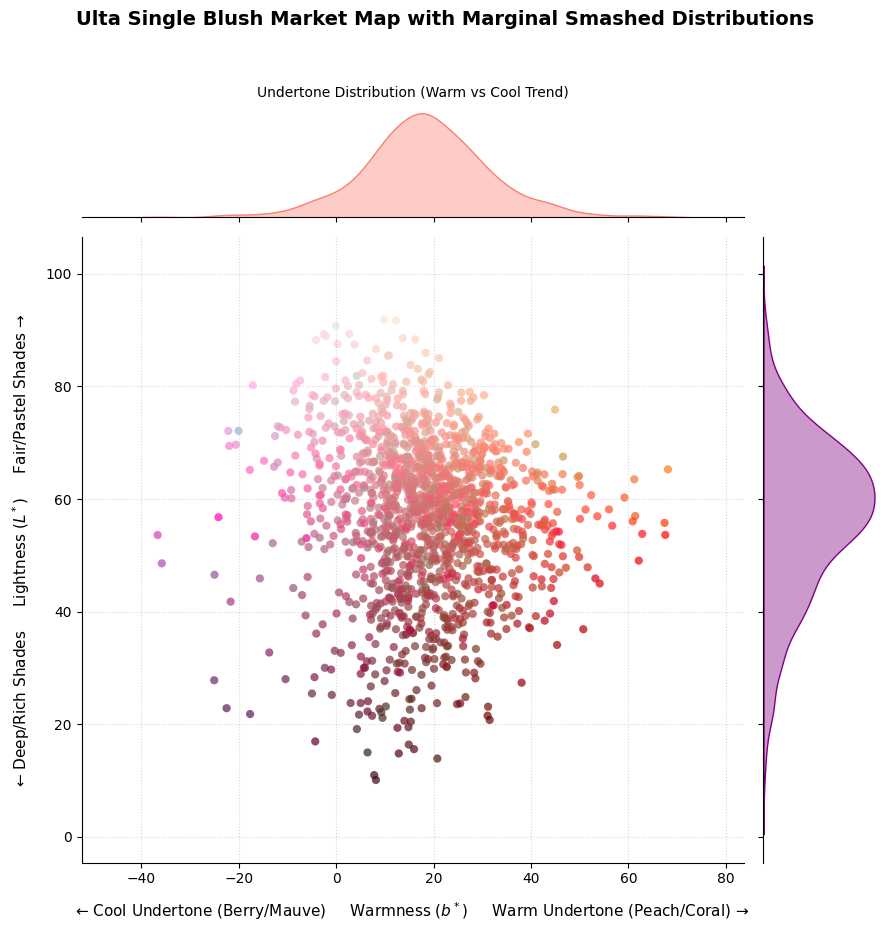

In [29]:
plot_4 = clean_single_blushes.dropna(subset=['L_axis', 'b_axis', 'hex_color'])

# 2. Convert RGB columns into a hex string for plotting
plot_4['hex_color'] = plot_4.apply(lambda r: '#%02x%02x%02x' % (int(r['rgb_r']), int(r['rgb_g']), int(r['rgb_b'])), axis=1)

# 3. Apply a tiny bit of random jitter so overlaps don't hide data density
np.random.seed(42)
plot_4['jitter_b'] = plot_4['lab_b'] + np.random.normal(0, 0.2, size=len(plot_4))
plot_4['jitter_L'] = plot_4['lab_L'] + np.random.normal(0, 0.2, size=len(plot_4))

# 4. Initialize the JointGrid
g = sns.JointGrid(data=plot_4, x='jitter_b', y='jitter_L', height=9)

# 5. Populate the central scatter map using the individual swatch colors
g.plot_joint(
    plt.scatter, 
    c=plot_4['hex_color'], 
    s=35, 
    alpha=0.7, 
    edgecolors='none'
)

# 6. Populate the "Smashed" marginal distributions safely using Seaborn's built-in hooks
# Top marginal (X-axis) gets the warmth/coolness curve
sns.kdeplot(data=plot_4, x='lab_b', ax=g.ax_marg_x, color='salmon', fill=True, alpha=0.4)
# Right marginal (Y-axis) gets the depth/value curve
sns.kdeplot(data=plot_4, y='lab_L', ax=g.ax_marg_y, color='purple', fill=True, alpha=0.4)

# 7. Labels and Clean Styling
g.ax_joint.set_xlabel('← Cool Undertone (Berry/Mauve)     Warmness ($b^*$)     Warm Undertone (Peach/Coral) →', fontsize=11, labelpad=10)
g.ax_joint.set_ylabel('← Deep/Rich Shades     Lightness ($L^*$)     Fair/Pastel Shades →', fontsize=11, labelpad=10)
g.ax_joint.grid(True, linestyle=':', alpha=0.5)

# Add titles to the sub-axes for maximum clarity
g.ax_marg_x.set_title("Undertone Distribution (Warm vs Cool Trend)", fontsize=10, pad=8)

plt.suptitle('Ulta Single Blush Market Map with Marginal Smashed Distributions', y=1.03, fontsize=14, fontweight='bold')
plt.tight_layout()

# Save and render
# plt.savefig('smashed_distributions_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

In [31]:
plot_5 = clean_single_blushes.dropna(subset=['lab_L', 'lab_b', 'rgb_r', 'rgb_g', 'rgb_b']).copy()

# 2. Convert RGB columns into a standard CSS hex string for Plotly to read
plot_5['hex_color'] = plot_5.apply(lambda r: '#%02x%02x%02x' % (int(r['rgb_r']), int(r['rgb_g']), int(r['rgb_b'])), axis=1)

# 3. Apply a tiny bit of random jitter so overlapping duplicate shades are both interactive
np.random.seed(42)
plot_5['jitter_b'] = plot_5['lab_b'] + np.random.normal(0, 0.2, size=len(plot_5))
plot_5['jitter_L'] = plot_5['lab_L'] + np.random.normal(0, 0.2, size=len(plot_5))

# 4. Create the Interactive Scatter Plot with Marginal Distributions
fig = px.scatter(
    plot_5, 
    x='jitter_b', 
    y='jitter_L',
    color='hex_color',                   # Tells Plotly how to map color strings
    color_discrete_map='identity',       # Forces Plotly to use the literal hex values instead of a color palette
    marginal_x='histogram',              # "Smashes" onto top X-axis as a distribution histogram
    marginal_y='histogram',              # "Smashes" onto right Y-axis as a distribution histogram
    title=f'<b>Interactive Ulta Single Blush Market Spectrum Map ({len(plot_5)} Shades)</b>',
    # Customize the hover tooltip box explicitly:
    hover_data={
        'brand': True,                   # Displays Brand
        'product_name': True,            # Displays Product Name
        'shade': True,                   # Displays Shade Name
        'price': ':$',                   # Displays Price formatted with a dollar sign
        'lab_L': ':.1f',                 # Displays true raw Lightness (1 decimal)
        'lab_b': ':.1f',                 # Displays true raw Warmness (1 decimal)
        'jitter_b': False,               # Hides the artificial jitter from the user box
        'jitter_L': False,               # Hides the artificial jitter from the user box
        'hex_color': False               # Hides raw hex code string
    },
    labels={
        'brand': 'Brand',
        'product_name': 'Product',
        'shade': 'Shade Name',
        'price': 'Price',
        'lab_L': 'Lightness (L*)',
        'lab_b': 'Warmness (b*)'
    }
)

# 5. Clean Up Layout, Styling, and Axis Descriptions
fig.update_layout(
    template='plotly_white',
    width=1100,
    height=950,
    title_font_size=16,
    showlegend=False,                     # Hides the massive 1,435-item legend column
    hoverlabel=dict(
        bgcolor='white',                 # Clean white background for tooltip
        font_size=12,
        font_family='Arial'
    )
)

# Style the main central grid axes
fig.update_xaxes(
    title_text='← Cool Undertone (Berry/Mauve)     <b>Warmness (b*)</b>     Warm Undertone (Peach/Coral) →',
    gridcolor='rgba(200, 200, 200, 0.2)',
    zerolinecolor='rgba(100, 100, 100, 0.3)',
    title_font_size=11
)

fig.update_yaxes(
    title_text='← Deep/Rich Shades     <b>Lightness (L*)</b>     Fair/Pastel Shades →',
    gridcolor='rgba(200, 200, 200, 0.2)',
    zerolinecolor='rgba(100, 100, 100, 0.3)',
    title_font_size=11
)

# 6. Save as an interactive webpage file and display
# fig.write_html('interactive_blush_market_map.html')
fig.show()

![Plot 5](../img/plot5)

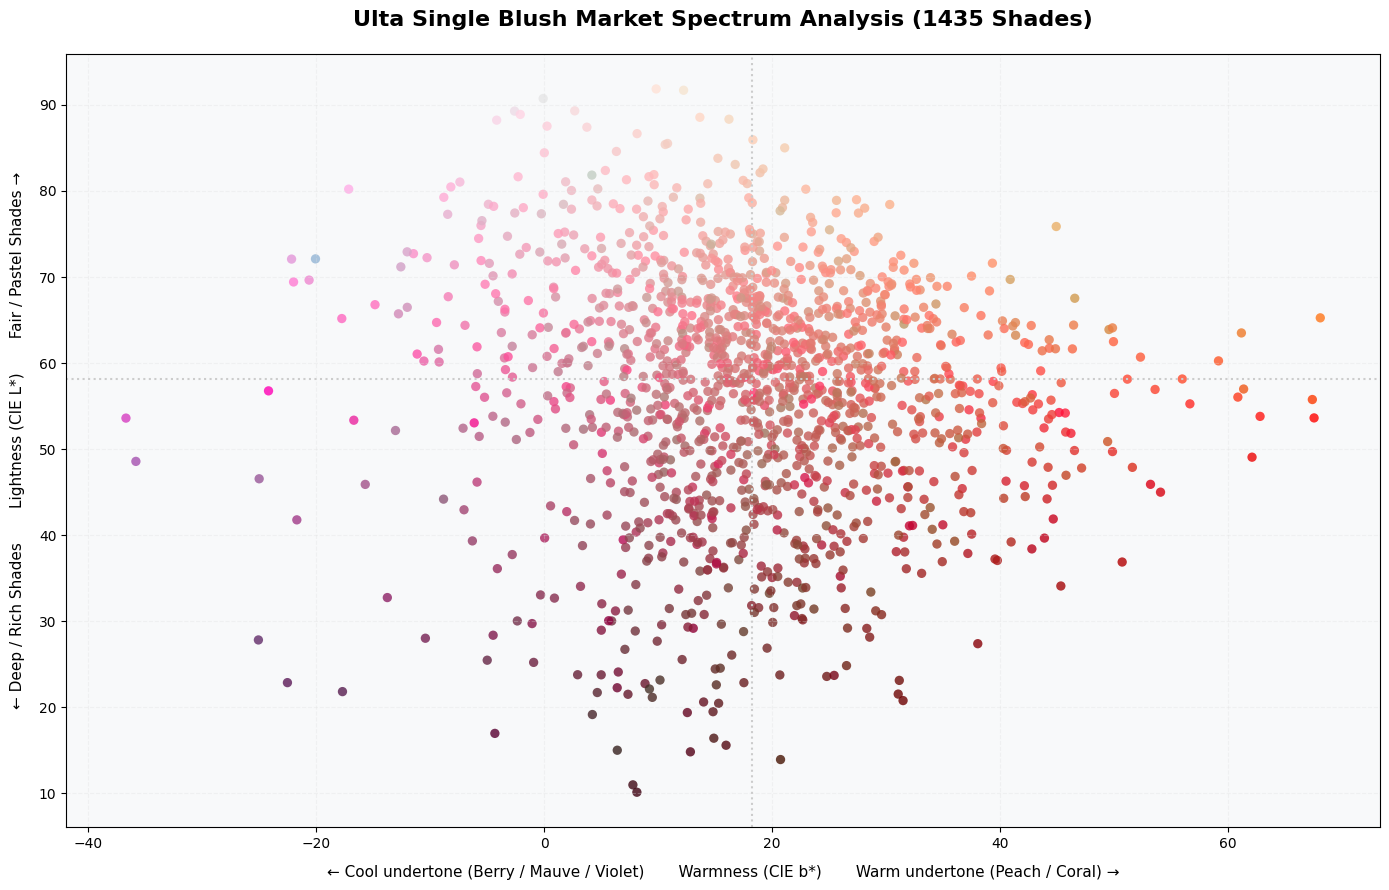

In [32]:
# 2. Clean up data: ensure we have numeric values and drop missing values
plot_6 = clean_single_blushes.dropna(subset=['lab_L', 'lab_b', 'rgb_r', 'rgb_g', 'rgb_b']).copy()

# 3. Vectorized conversion of RGB columns to Hex strings for matplotlib
def row_to_hex(row):
    return '#%02x%02x%02x' % (int(row['rgb_r']), int(row['rgb_g']), int(row['rgb_b']))

plot_6['hex_color'] = plot_6.apply(row_to_hex, axis=1)

# 4. Apply a tiny amount of visual jitter so overlapping points are visible
np.random.seed(42) # For consistent plotting
jitter_x = np.random.normal(0, 0.2, size=len(plot_6))
jitter_y = np.random.normal(0, 0.2, size=len(plot_6))

# 5. Build the Spectrum Visualization
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor('#F8F9FA')  # Light off-white background

# Map b onto X-axis, and L onto Y-axis
scatter = ax.scatter(
    x=plot_6['lab_b'] + jitter_x,
    y=plot_6['lab_L'] + jitter_y,
    c=plot_6['hex_color'],
    s=45,
    alpha=0.8,
    edgecolors='none'  # Clean edges makes it look like a smooth gradient cloud
)

# 6. Styling and Strategic Context Lines
ax.set_title(f'Ulta Single Blush Market Spectrum Analysis ({len(plot_6)} Shades)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('← Cool undertone (Berry / Mauve / Violet)       Warmness (CIE b*)       Warm undertone (Peach / Coral) →', fontsize=11, labelpad=10)
ax.set_ylabel('← Deep / Rich Shades       Lightness (CIE L*)       Fair / Pastel Shades →', fontsize=11, labelpad=10)

# Add quadrant lines using medians to easily spot empty market quadrants
median_b = plot_6['lab_b'].median()
median_L = plot_6['lab_L'].median()

ax.axvline(x=median_b, color='#CCCCCC', linestyle=':', linewidth=1.5, label=f'Median Warmth ({median_b:.1f})')
ax.axhline(y=median_L, color='#CCCCCC', linestyle=':', linewidth=1.5, label=f'Median Lightness ({median_L:.1f})')

# Clean up layout adjustments
ax.grid(True, linestyle='--', alpha=0.3, color='#DDDDDD')
plt.tight_layout()


# plt.savefig('blush_market_gap_analysis.png', dpi=300) # Save plot to disk
plt.show()

### Plots of Palette Blushes

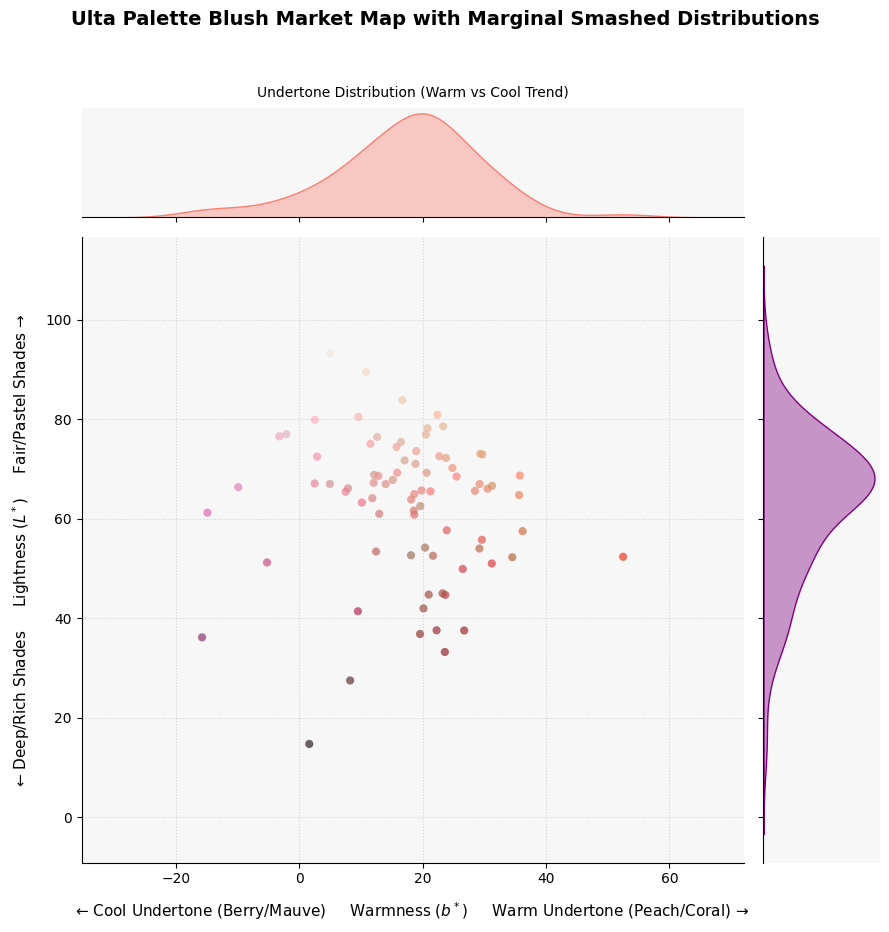

In [40]:
plot_6 = clean_palettes.dropna(subset=['L_axis', 'b_axis', 'hex_color'])

# 2. Convert RGB columns into a hex string for plotting
plot_6['hex_color'] = plot_6.apply(lambda r: '#%02x%02x%02x' % (int(r['rgb_r']), int(r['rgb_g']), int(r['rgb_b'])), axis=1)

# 3. Apply a tiny bit of random jitter so overlaps don't hide data density
np.random.seed(42)
plot_6['jitter_b'] = plot_6['lab_b'] + np.random.normal(0, 0.2, size=len(plot_6))
plot_6['jitter_L'] = plot_6['lab_L'] + np.random.normal(0, 0.2, size=len(plot_6))

# 4. Initialize the JointGrid
g = sns.JointGrid(data=plot_6, x='jitter_b', y='jitter_L', height=9)

# 5. Populate the central scatter map using the individual swatch colors
g.plot_joint(
    plt.scatter, 
    c=plot_6['hex_color'], 
    s=35, 
    alpha=0.7, 
    edgecolors='none'
)

# 6. Populate the "Smashed" marginal distributions safely using Seaborn's built-in hooks
# Top marginal (X-axis) gets the warmth/coolness curve
sns.kdeplot(data=plot_6, x='lab_b', ax=g.ax_marg_x, color='salmon', fill=True, alpha=0.4)
# Right marginal (Y-axis) gets the depth/value curve
sns.kdeplot(data=plot_6, y='lab_L', ax=g.ax_marg_y, color='purple', fill=True, alpha=0.4)

# 7. Labels and Clean Styling
g.ax_joint.set_xlabel('← Cool Undertone (Berry/Mauve)     Warmness ($b^*$)     Warm Undertone (Peach/Coral) →', fontsize=11, labelpad=10)
g.ax_joint.set_ylabel('← Deep/Rich Shades     Lightness ($L^*$)     Fair/Pastel Shades →', fontsize=11, labelpad=10)
g.ax_joint.grid(True, linestyle=':', alpha=0.5)

# Add titles to the sub-axes for maximum clarity
g.ax_marg_x.set_title("Undertone Distribution (Warm vs Cool Trend)", fontsize=10, pad=8)

plt.suptitle('Ulta Palette Blush Market Map with Marginal Smashed Distributions', y=1.03, fontsize=14, fontweight='bold')
plt.tight_layout()

# Save and render
# plt.savefig('smashed_distributions_fixed.png', dpi=300, bbox_inches='tight')
plt.show()